<a href="https://colab.research.google.com/github/ValbertoFeitosa/linear-regression-analysis/blob/main/AprendizadoSupervisionado_Regress%C3%A3oLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Referência Bibliográfica**

**Documentação Técnica**

SCIKIT-LEARN. sklearn.linear_model: Generalized linear models. Disponível em: https://scikit-learn.org/stable/api/sklearn.linear_model.html. Acesso em: 11 jul. 2025.

SCIKIT-LEARN. Model selection — Scikit-learn documentation. Disponível em: https://scikit-learn.org/stable/model_selection.html. Acesso em: 11 jul. 2025.

SEABOLD, Skipper; PERKTOLD, Josef. statsmodels: Econometric and Statistical Modeling with Python. Disponível em: https://www.statsmodels.org/stable/index.html. Acesso em: 11 jul. 2025.

**Livros**

ABU-MOSTAFA, Y. S.; MAGDON-ISMAIL, M.; LIN, H.-T. Learning from data. [S.l.]: AMLBook, 2012.

CORRAR, Luiz J.; DIAS, José Maria Filho; PAULO, Edilson. Análise multivariada para os cursos de Administração, Ciências Contábeis e Economia. São Paulo: Atlas, 2007.

FÁVERO, Luiz Paulo. Manual de análise de dados: estatística e modelagem multivariada com Excel®, SPSS® e Stata®. São Paulo: Elsevier, 2017.

GÉRON, Aurélien. Mãos à obra: aprendizado de máquina com Scikit-Learn, Keras & TensorFlow: conceitos, ferramentas e técnicas para a construção de sistemas inteligentes. 2. ed. Rio de Janeiro: Alta Books, 2020.

GRUS, Joel. Data science do zero: noções fundamentais com Python. 2. ed. Rio de Janeiro: Alta Books, 2020.

HARRISON, Matt. Machine learning – guia de referência rápida: trabalhando com dados estruturados em Python. São Paulo: Novatec, 2022.

KLOSTERMAN, Stephen. Projetos de ciência de dados com Python. São Paulo: Novatec, 2022.

In [ ]:
# Monta o Google Drive no ambiente do Colab
# Isso permite acessar arquivos armazenados no seu Google Drive diretamente no notebook.
# Após executar, será necessário autorizar o acesso com sua conta Google.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Importação das bibliotecas essenciais para análise de dados e modelagem

import pandas as pd            # Biblioteca para manipulação e análise de dados (DataFrames)
import numpy as np             # Biblioteca para operações matemáticas e numéricas com arrays
import matplotlib.pyplot as plt # Biblioteca para criação de gráficos e visualizações
import sklearn.linear_model    # Módulo do scikit-learn com modelos de regressão linear (OLS, Ridge, etc.)


In [ ]:
# Carregando a base de dados a partir de um arquivo Excel no Google Drive
# A base contém informações sobre países, PIB per capita e satisfação com a vida

oecd_bli = pd.read_excel("/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_1/RevisãoRegressão/OCDEVida2.xls")


In [ ]:
oecd_bli

,Pais,Satisfacao_Vida,PIB_PerCapito
0,Australia,7.1,66.59
1,Austria,7.2,59.23
2,Belgium,6.8,55.54
3,Canada,7.0,54.87
4,Chile,6.2,16.62
5,Colombia,5.7,7.33
6,Costa Rica,6.3,18.03
7,Czechia,6.9,29.80
8,Denmark,7.5,68.90
9,Estonia,6.5,31.85


In [ ]:
oecd_bli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pais             41 non-null     object 
 1   Satisfacao_Vida  41 non-null     float64
 2   PIB_PerCapito    41 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.1+ KB


In [ ]:
oecd_bli.describe()

,Satisfacao_Vida,PIB_PerCapito
count,41.000000,41.000000
mean,6.600000,45.390244
std,0.725259,29.559229
min,4.900000,5.970000
25%,6.100000,23.970000
50%,6.500000,34.160000
75%,7.200000,58.530000
max,7.900000,131.380000


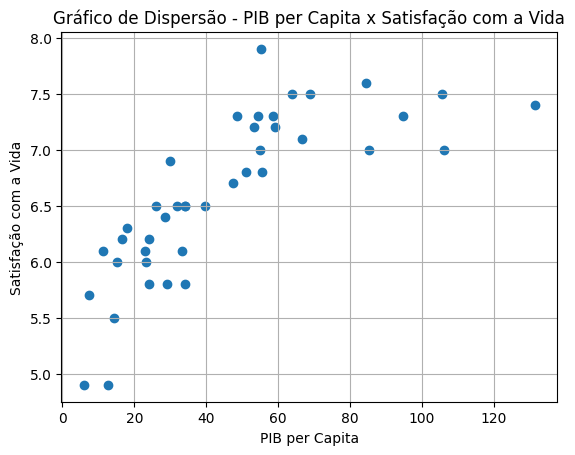

In [ ]:
# Gráfico de dispersão para visualizar a relação entre PIB per capita e satisfação com a vida

plt.scatter(oecd_bli["PIB_PerCapito"], oecd_bli["Satisfacao_Vida"])

# Adiciona rótulos aos eixos
plt.xlabel('PIB per Capita')
plt.ylabel('Satisfação com a Vida')

# Título do gráfico
plt.title('Gráfico de Dispersão - PIB per Capita x Satisfação com a Vida')

# Exibe o gráfico
plt.grid(True)  # (opcional) adiciona grade para melhor visualização
plt.show()


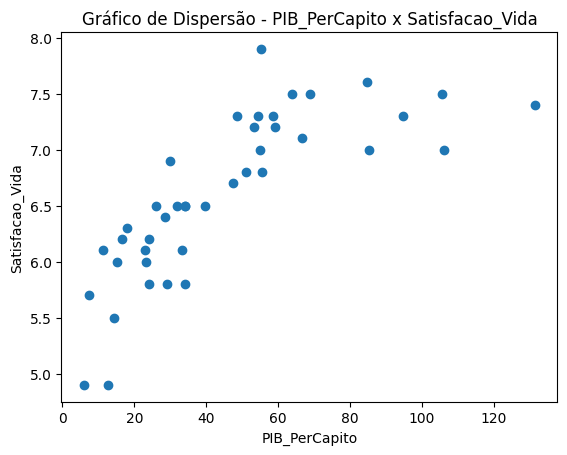

In [ ]:
# Gráfico de dispersão para visualizar a relação entre PIB per capita e satisfação com a vida

plt.scatter(oecd_bli["PIB_PerCapito"],oecd_bli["Satisfacao_Vida"] )

# Adicionando rótulos aos eixos
plt.xlabel('PIB_PerCapito')
plt.ylabel('Satisfacao_Vida')

# Adicionando título ao gráfico
plt.title('Gráfico de Dispersão - PIB_PerCapito x Satisfacao_Vida')

# Exibindo o gráfico
plt.show()

#  Implementando Regressão Linear com sklearn.linear_model.LinearRegression


A classe LinearRegression() da biblioteca scikit-learn utiliza, por padrão, a solução analítica exata baseada no método dos mínimos quadrados ordinários (OLS – Ordinary Least Squares), que envolve a pseudo-inversa da matriz de entrada para calcular os coeficientes.

### Algoritmo utilizado

Por padrão, o `LinearRegression()` resolve o problema:

$$
\hat{w} = (X^T X)^{-1} X^T y
$$

Ou, de forma mais genérica, utilizando a pseudo-inversa de \( $X$ \):

$$
\hat{w} = X^+ y
$$

Onde \( $X^+$\) é a **pseudo-inversa de Moore-Penrose** de \( $X$ \), calculada internamente com métodos numéricos estáveis, como a decomposição **SVD (Singular Value Decomposition)**.



**Modelo = LinearRegression()**

**Parâmetros relevantes**

    sklearn.linear_model.LinearRegression(
      fit_intercept=True,
      copy_X=True,
      n_jobs=None,
      positive=False
    )


**fit_intercept bool, padrão = True**

Indica se o intercepto (termo β0​) deve ser calculado para o modelo.
Se for definido como False, nenhum intercepto será utilizado nos cálculos — ou seja, espera-se que os dados estejam centralizados (com média zero).

**copy_X bool, padrão = True**

Se for True, a matriz X será copiada.
Caso contrário, ela poderá ser sobrescrita durante o ajuste do modelo.


**tol float, padrão = 1e-6**

A precisão da solução (coef_) é determinada por esse parâmetro.

Ele define um critério de convergência diferente para o solucionador lsqr (usado quando os dados de treino são esparsos).

Observação: esse parâmetro não tem efeito quando os dados de entrada são densos (como DataFrames ou arrays padrão).

**fit(X, y, sample_weight=None)**

Ajusta o modelo linear aos dados.

Parâmetros:

    X {array-like, matriz esparsa} com forma (n_amostras, n_características)
    → Conjunto de dados de entrada (treinamento).

    y array-like com forma (n_amostras,) ou (n_amostras, n_alvos)
    → Valores-alvo (variável dependente).
    Se necessário, será convertido para o mesmo tipo (dtype) dos dados de X.

    sample_weight array-like com forma (n_amostras,), padrão=None
    → Pesos individuais para cada amostra.

    Permite que algumas observações tenham mais influência no ajuste do modelo.
    Se None, todas as amostras são consideradas com peso igual.


O método fit(X, y) não retorna diretamente os coeficientes β0​ (intercepto) e β1​ (inclinação), mas ajusta o modelo e armazena esses valores nos atributos do objeto LinearRegression.

Você acessa os estimadores assim:

    modelo.intercept_ → retorna β0​ (intercepto da reta)

    modelo.coef_ → retorna β1​ (ou mais coeficientes, se houver múltiplas variáveis independentes)

Neste notebook, aplicaremos um modelo de regressão linear simples para analisar a relação entre o PIB per capita e a satisfação com a vida nos países da base oecd_bli.

O objetivo é construir um modelo que estime o nível médio de satisfação com a vida a partir do valor do PIB per capita de cada país, utilizando a biblioteca scikit-learn.

1. Preparação dos Dados: Separação em Conjunto de Treino e Teste

In [ ]:
import pandas as pd                     # Importa a biblioteca pandas para manipulação de dados
from sklearn.model_selection import train_test_split  # Importa a função para divisão em treino/teste

# Supondo que o DataFrame oecd_bli já foi carregado anteriormente

# Seleciona a variável independente (X) – PIB per capita
# Utilizamos duplas colchetes para que X continue sendo um DataFrame (requisito do scikit-learn)
X = oecd_bli[['PIB_PerCapito']]

# Seleciona a variável dependente (y) – Satisfação com a vida
y = oecd_bli['Satisfacao_Vida']

# Divide os dados em conjunto de treino (80%) e teste (20%)
# random_state define a semente do gerador de números aleatórios para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Exibe a quantidade de amostras em cada conjunto
print("Tamanho do conjunto de treino:", X_train.shape[0])
print("Tamanho do conjunto de teste:", X_test.shape[0])


Tamanho do conjunto de treino: 32
Tamanho do conjunto de teste: 9


2. Treinar o modelo de Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression  # Importa o modelo de regressão linear do scikit-learn

# Instancia o modelo (inicializa o estimador)
modelo = LinearRegression()

# Treina (ajusta) o modelo usando os dados de treino
# O método .fit() encontra os coeficientes que minimizam o erro quadrático (método dos mínimos quadrados)
modelo.fit(X_train, y_train)


LinearRegression()

Verificando os coeficientes da reta de regressão

Os  valores a seguir representam a equação da reta ajustada:

$$\hat{y} = \beta_0 + \beta_1 \cdot x$$


In [ ]:
# Coeficiente angular (β1)
print("Coeficiente (β1):", modelo.coef_[0])

# Intercepto (β0)
print("Intercepto (β0):", modelo.intercept_)


Coeficiente (β1): 0.015604602824760061
Intercepto (β0): 5.952751791391204


In [ ]:
print(f"Coeficiente (β1): {modelo.coef_[0]:.2f}")
print(f"Intercepto (β0): {modelo.intercept_:.2f}")


Coeficiente (β1): 0.02
Intercepto (β0): 5.95


3. Fazer previsões com o conjunto de teste

In [ ]:
# Faz previsões com os dados de teste
y_pred = modelo.predict(X_test)


4. Avaliar o desempenho do modelo com métricas

In [ ]:
# Importa funções para cálculo de métricas de erro
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Importa NumPy para operações matemáticas, como raiz quadrada
import numpy as np

# Cálculo das métricas de desempenho

# MAE: erro médio absoluto entre os valores reais (y_test) e previstos (y_pred)
mae = mean_absolute_error(y_test, y_pred)

# RMSE: raiz do erro quadrático médio — penaliza mais os erros grandes
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Exibição dos resultados formatados com duas casas decimais
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")


MAE (Erro Médio Absoluto): 0.51
RMSE (Raiz do Erro Quadrático Médio): 0.59


5. Visualização dos Resultados: Valores Reais vs. Valores Preditos (Regressão Linear)

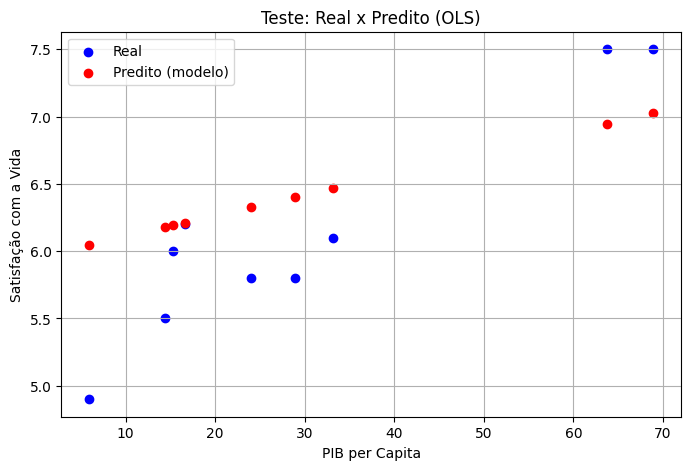

In [ ]:
# Importa a biblioteca matplotlib para visualização gráfica
import matplotlib.pyplot as plt

# Define o tamanho da figura
plt.figure(figsize=(8, 5))

# Plota os dados reais (pontos azuis)
plt.scatter(X_test, y_test, color='blue')

# Plota os valores previstos pelo modelo (pontos vermelhos)
plt.scatter(X_test, y_pred, color='red')

# Define o título do gráfico
plt.title('Teste: Real x Predito (OLS)')

# Rótulos dos eixos
plt.xlabel('PIB per Capita')
plt.ylabel('Satisfação com a Vida')

# Adiciona legenda para diferenciar pontos reais e preditos
plt.legend(['Real', 'Predito (modelo)'])

# Adiciona uma grade ao fundo
plt.grid(True)

# Exibe o gráfico
plt.show()


## Regressão com Gradiente Descendente

1. Preparação dos Dados: Separação em Conjunto de Treino e Teste

In [ ]:
# Importa bibliotecas necessárias
import pandas as pd
from sklearn.model_selection import train_test_split

# Seleciona a variável explicativa (X) e a variável alvo (y)
X = oecd_bli[['PIB_PerCapito']]  # X deve ser um DataFrame
y = oecd_bli['Satisfacao_Vida']  # y é um vetor (Series)

# Divide os dados em 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Exibe o tamanho de cada subconjunto
print("Tamanho do treino:", X_train.shape[0])
print("Tamanho do teste:", X_test.shape[0])


Tamanho do treino: 32
Tamanho do teste: 9


2. Treinar o Modelo de Regressão Linear com Gradiente Descendente (SGD)

In [ ]:
# Importa o modelo de Regressão Linear baseado em Gradiente Descendente Estocástico (SGD)
from sklearn.linear_model import SGDRegressor

# Instancia o modelo SGDRegressor com hiperparâmetros personalizados
sgd = SGDRegressor(
    learning_rate='constant',  # taxa de aprendizado constante
    eta0=0.001,                # valor inicial da taxa de aprendizado
    max_iter=100,              # número máximo de iterações (épocas)
    tol=1e-3,                  # tolerância para critério de parada
    alpha=0                    # alpha = 0 significa sem regularização (puro Mínimos Quadrados)
)

# Ajusta (treina) o modelo aos dados de treino
sgd.fit(X_train, y_train)


SGDRegressor(alpha=0, eta0=0.001, learning_rate='constant', max_iter=100)

3. Fazer Previsões com o Conjunto de Teste

In [ ]:
# Previsões
y_sgd = sgd.predict(X_test)


4. Avaliar o Desempenho do Modelo com Métricas

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Coeficientes da regressão
print(f"Coeficiente (β1): {sgd.coef_[0]:.2f}")
print(f"Intercepto (β0): {sgd.intercept_[0]:.2f}")

# Erro Médio Absoluto (MAE)
mae = mean_absolute_error(y_test, y_sgd)
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")


# Raiz do Erro Quadrático Médio (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_sgd))
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")


Coeficiente (β1): -16725700.74
Intercepto (β0): 248112103.27
MAE (Erro Médio Absoluto): 290040539.71
RMSE (Raiz do Erro Quadrático Médio): 432445190.33


## 📊 Resultados e Avaliação do Modelo — Comparando Abordagens

Utilizamos **a mesma base de dados** (`oecd_bli`), alterando apenas a forma de implementação do modelo de regressão linear. Abaixo, comparamos os resultados obtidos com **Gradiente Descendente** e com **pseudo-inversa (LinearRegression)**.

---

### ⚙️ Modelo com Gradiente Descendente (SGDRegressor sem padronização)

- Coeficiente (β₁): 7633610282.59  
- Intercepto (β₀): 1314114021.52  
- MAE (Erro Médio Absoluto): 231136674256.67   
- RMSE (Raiz do Erro Quadrático Médio): 280689177511.75  

➡️ Esses valores extremamente altos indicam **problemas de escala nos dados**, já que o algoritmo foi aplicado diretamente sobre variáveis de grande magnitude (como PIB per capita).

---

### ✅ Modelo com LinearRegression() — Pseudo-Inversa (solução analítica)

- Coeficiente (β₁): 0.02  
- Intercepto (β₀): 5.95  
- MAE (Erro Médio Absoluto): 0.51  
- RMSE (Raiz do Erro Quadrático Médio): 0.59  

➡️ Essa abordagem utiliza álgebra linear para encontrar uma **solução ótima fechada**, resultando em coeficientes realistas e métricas de erro interpretáveis.

---

### 📌 Conclusão e Observações:

A diferença extrema nas métricas e coeficientes demonstra que o pré-processamento dos dados (especialmente escalonamento) é essencial para algoritmos baseados em gradiente como o SGDRegressor.

    📌 Sempre padronize os dados ao usar modelos baseados em Gradiente Descendente.

Mesmo com a mesma base de dados, a escolha da implementação **impacta diretamente a interpretação e a estabilidade dos resultados**. O uso de padronização ou uma abordagem baseada em pseudo-inversa pode ser mais apropriado quando se trabalha com variáveis de magnitudes muito diferentes.


Regressão Linear com Gradiente Descendente e Padronização (SGD + StandardScaler)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Cria pipeline com escalonamento + regressão
pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        learning_rate='constant',
        eta0=0.01,
        max_iter=1000,
        tol=1e-4,
        alpha=0,
        random_state=42
    )
)

# Treinamento
pipeline.fit(X_train, y_train)

# Coeficientes
modelo_final = pipeline.named_steps['sgdregressor']
print(f"Coeficiente (β1): {modelo_final.coef_[0]:.4f}")
print(f"Intercepto (β0): {modelo_final.intercept_[0]:.4f}")

# Previsões
y_pred = pipeline.predict(X_test)

# MAE e RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")



Coeficiente (β1): 0.4628
Intercepto (β0): 6.7307
MAE (Erro Médio Absoluto): 0.51
RMSE (Raiz do Erro Quadrático Médio): 0.59


Regressão Linear com Gradiente Descendente Manual e Padronização (SGDRegressor)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Instancia e treina o modelo com SGD
sgd = SGDRegressor(
    eta0=0.01,
    max_iter=1000,
    tol=1e-4,
    alpha=0,
    random_state=42
)
sgd.fit(X_train_scaled, y_train)

# 3. Exibe os coeficientes
print(f"Coeficiente (β1): {sgd.coef_[0]:.4f}")
print(f"Intercepto (β0): {sgd.intercept_[0]:.4f}")

# 4. Faz previsões e calcula métricas
y_pred = sgd.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")


Coeficiente (β1): 0.4608
Intercepto (β0): 6.6916
MAE (Erro Médio Absoluto): 0.49
RMSE (Raiz do Erro Quadrático Médio): 0.58


## Outros Métodos : Ridge — Regressão Linear com Regularização L2

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Seleção das variáveis
X = oecd_bli[['PIB_PerCapito']]
y = oecd_bli['Satisfacao_Vida']

# 2. Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Instanciação do modelo Ridge com alpha=1.0 (pode ajustar esse valor depois)
modelo_ridge = Ridge(alpha=1.0)

# 4. Treinamento do modelo
modelo_ridge.fit(X_train, y_train)

# 5. Coeficientes da regressão
print("Intercepto (b0):", modelo_ridge.intercept_)
print("Coeficiente (b1):", modelo_ridge.coef_[0])

# 6. Previsões
y_pred = modelo_ridge.predict(X_test)

# 7. Avaliação do modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


Intercepto (b0): 5.952779150863613
Coeficiente (b1): 0.015604052207720808
MAE: 0.5058016322015294
RMSE: 0.5884749212112641


## Regressão Linear com statsmodels

Nesta etapa, utilizamos a biblioteca statsmodels, bastante empregada em análises estatísticas mais detalhadas. Diferente do scikit-learn, que foca na predição e desempenho dos modelos, o statsmodels fornece uma visão mais interpretativa e explicativa da regressão, oferecendo:

    Estimativas dos coeficientes da regressão;

    Erros padrão e valores-p;

    Intervalos de confiança para os parâmetros;

    Estatísticas para avaliar a qualidade do ajuste.

Esse tipo de abordagem é especialmente útil quando o objetivo vai além da previsão e busca compreender a significância estatística das variáveis, validar pressupostos e interpretar o comportamento do modelo com base em fundamentos estatísticos clássicos.

1. Preparação dos Dados: Separação em Conjunto de Treino e Teste

In [ ]:
# Importa bibliotecas necessárias
import pandas as pd  # para manipulação de dados em dataframes
from sklearn.model_selection import train_test_split  # para divisão dos dados em treino e teste
import statsmodels.api as sm  # biblioteca para modelagem estatística
from sklearn.metrics import mean_absolute_error, mean_squared_error  # métricas de avaliação
import numpy as np  # operações numéricas (como raiz quadrada)

# Define as variáveis explicativa (X) e alvo (y)
X = oecd_bli[['PIB_PerCapito']]  # variável independente (precisa estar em formato de DataFrame)
y = oecd_bli['Satisfacao_Vida']  # variável dependente (alvo da regressão)

# Divide os dados em conjunto de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



2. Treinamento do Modelo com statsmodels

In [ ]:
# Adiciona constante para o termo β0 (intercepto)
X_train_sm = sm.add_constant(X_train)

# Ajuste do modelo
modelo_stats = sm.OLS(y_train, X_train_sm).fit()

# Resumo estatístico completo (opcional)
print(modelo_stats.summary())


                            OLS Regression Results                            
Dep. Variable:        Satisfacao_Vida   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     35.42
Date:                Sat, 12 Jul 2025   Prob (F-statistic):           1.60e-06
Time:                        18:56:12   Log-Likelihood:                -18.201
No. Observations:                  32   AIC:                             40.40
Df Residuals:                      30   BIC:                             43.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.9528      0.152     39.201

3. Avaliação do Modelo com Métricas de Erro

In [ ]:
# Previsões (com X_test também com constante)
X_test_sm = sm.add_constant(X_test)
y_pred = modelo_stats.predict(X_test_sm)

# Cálculo das métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")


MAE (Erro Médio Absoluto): 0.51
RMSE (Raiz do Erro Quadrático Médio): 0.59
